# Retrain MTDShield DDQN Model (Tay 2024)

This notebook retrains Joo Kai Tay's flagship Double Deep Q-Network (DDQN) model for
AI-driven Moving Target Defence (MTD) deployment.

**Best hyperparameters from thesis evaluation:**
- `gamma = 0.85` (discount factor, best of 10 tested: score 10.77)
- `epsilon = 0.5, decay = 0.99` (exploration, best of 24 tested: score 11.00)
- `train_start = 2000` (experience buffer, best of 4 tested: score 10.39)

**Architecture:** Dual-pathway DDQN with static feature extraction (Dense) and
temporal analysis (LSTM), fused before Q-value output. 5 static + 6 time-series
input features, 5 discrete actions (4 MTD techniques + do nothing).

**Reference:** Tay, J.K. (2024). *Using Artificial Intelligence to Automate the
Deployment of Moving Target Defence Operations*. GENG5512, UWA.

## 1. Imports & Setup

Use the Python (mtdsim) kernel from the project environment.yml.

Do not run pip install tensorflow inside this notebook, because it can overwrite
Conda-managed NumPy/Pandas binaries and break imports.

In [10]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.disable(logging.CRITICAL)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy
import random
from collections import deque

# TensorFlow / Keras
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import load_model

# MTDSim core
from mtdsim.network import TimeNetwork
from mtdsim.attacker import Adversary, AttackOperation
from mtdsim.defender import MTDOperation
from mtdsim.defender.techniques import (
    CompleteTopologyShuffle, IPShuffle, OSDiversity, ServiceDiversity,
)
from mtdsim.data import constants
from mtdsim.stats.evaluation import Evaluation
from mtdsim.stats.security_metric_statistics import SecurityMetricStatistics

# MTDSim AI (DDQN)
from mtdsim.ai.mtd_ai import create_network, update_target_model
from mtdsim.ai.mtd_ai_training import MTDAITraining
from mtdsim.ai.mtd_ai_operation import MTDAIOperation

print("All imports successful.")

All imports successful.


## 2. Hyperparameters

Best values identified through Tay's systematic evaluation (Sections 5.2.1-5.2.3).

| Parameter | Value | Source |
|---|---|---|
| gamma | 0.85 | Fig 3: bell-shaped curve, peak at 0.85 |
| epsilon | 0.5 | Fig 4: low epsilon favours exploitation |
| epsilon_decay | 0.99 | Fig 4b: best subplot |
| train_start | 2000 | Fig 5: most stable training |
| batch_size | 64 | Used in gamma experiments |

In [11]:
# ── Architecture ──────────────────────────────────────────────────────────────
# Matches current mtdsim.ai feature set (5 static + 6 time-series)
STATE_SIZE = 5        # host_compromise_ratio, attack_path_exposure, overall_asr_avg, roa, risk
TIME_SERIES_SIZE = 6  # mtd_freq, overall_mttc_avg, time_since_last_mtd, shortest_path_variability, ip_variability, attack_type
ACTION_SIZE = 5       # do_nothing(0), CompleteTopologyShuffle(1), IPShuffle(2), OSDiversity(3), ServiceDiversity(4)

# ── Best hyperparameters (Tay 2024 thesis) ────────────────────────────────────
GAMMA = 0.85
EPSILON = 0.5
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.99
BATCH_SIZE = 64
TRAIN_START = 2000

# ── Simulation settings ──────────────────────────────────────────────────────
EPISODES = 100
FINISH_TIME = 15000
TOTAL_NODES = 100
MTD_INTERVAL = 200

# ── Feature configuration (must match MTDAITraining.get_state_and_time_series) ─
FEATURES = {
    "static": [
        "host_compromise_ratio",
        "attack_path_exposure",
        "overall_asr_avg",
        "roa",
        "risk",
    ],
    "time": [
        "mtd_freq",
        "overall_mttc_avg",
        "time_since_last_mtd",
        "shortest_path_variability",
        "ip_variability",
        "attack_type",
    ],
}

# ── MTD action space (order matters: action 1-4 maps to index 0-3) ───────────
MTD_STRATEGIES = [
    CompleteTopologyShuffle,  # action 1
    IPShuffle,               # action 2
    OSDiversity,             # action 3
    ServiceDiversity,        # action 4
]

# ── Model save path ──────────────────────────────────────────────────────────
MODEL_PATH = "../src/mtdsim/ai/models/main_network_flagship.h5"

print(f"Training config: {EPISODES} episodes, {FINISH_TIME}s sim time, {TOTAL_NODES} nodes")
print(f"DDQN architecture: state={STATE_SIZE}, time_series={TIME_SERIES_SIZE}, actions={ACTION_SIZE}")
print(f"Hyperparams: gamma={GAMMA}, eps={EPSILON}, decay={EPSILON_DECAY}, batch={BATCH_SIZE}, train_start={TRAIN_START}")

Training config: 100 episodes, 15000s sim time, 100 nodes
DDQN architecture: state=5, time_series=6, actions=5
Hyperparams: gamma=0.85, eps=0.5, decay=0.99, batch=64, train_start=2000


## 3. Train the DDQN Model

Each episode runs a full SimPy simulation where the DDQN agent learns to select
MTD techniques. The training loop follows `execute_ai_training` from the original
experiments (commit `7b394db`), adapted for the new `mtdsim` package structure.

The experience replay `memory` persists across episodes so the agent accumulates
diverse experiences. The target network is updated every 10 episodes to stabilise
Q-value estimates (Double DQN).

In [12]:
# Create main and target DDQN networks
main_network = create_network(STATE_SIZE, ACTION_SIZE, TIME_SERIES_SIZE)
target_network = create_network(STATE_SIZE, ACTION_SIZE, TIME_SERIES_SIZE)
target_network.set_weights(main_network.get_weights())

# Experience replay buffer (shared across episodes)
memory = deque(maxlen=2000)

# Training tracking
epsilon = EPSILON
training_log = []

print("DDQN networks created.")
main_network.summary()

DDQN networks created.
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 5)]          0           []                               
                                                                                                  
 input_6 (InputLayer)           [(None, 6, 1)]       0           []                               
                                                                                                  
 dense_8 (Dense)                (None, 128)          768         ['input_5[0][0]']                
                                                                                                  
 lstm_4 (LSTM)                  (None, 6, 64)        16896       ['input_6[0][0]']                
                                                                     

In [ ]:
%%time

for episode in range(EPISODES):
    # Fresh simulation environment each episode
    env = simpy.Environment()
    end_event = env.event()
    security_metrics = SecurityMetricStatistics()

    # Create network and adversary
    network = TimeNetwork(
        total_nodes=TOTAL_NODES,
        total_endpoints=5,
        total_subnets=8,
        total_layers=4,
        total_database=2,
        terminate_compromise_ratio=0.8,
    )
    adversary = Adversary(network=network, attack_threshold=constants.ATTACKER_THRESHOLD)

    # Start attack process
    attack_op = AttackOperation(env=env, end_event=end_event, adversary=adversary, proceed_time=0)
    attack_op.proceed_attack()

    # Start MTD AI training process
    mtd_training = MTDAITraining(
        security_metric_record=security_metrics,
        features=FEATURES,
        env=env,
        end_event=end_event,
        network=network,
        attack_operation=attack_op,
        scheme="mtd_ai",
        adversary=adversary,
        proceed_time=0,
        mtd_trigger_interval=MTD_INTERVAL,
        custom_strategies=MTD_STRATEGIES,
        main_network=main_network,
        target_network=target_network,
        memory=memory,
        gamma=GAMMA,
        epsilon=epsilon,
        epsilon_min=EPSILON_MIN,
        epsilon_decay=EPSILON_DECAY,
        train_start=TRAIN_START,
        batch_size=BATCH_SIZE,
    )
    mtd_training.proceed_mtd()

    # Run simulation
    env.run(until=FINISH_TIME)

    # Track progress
    compromised = len(adversary.get_compromised_hosts())
    training_log.append({
        "episode": episode,
        "epsilon": epsilon,
        "compromised_hosts": compromised,
        "memory_size": len(memory),
    })

    # Update target network every 10 episodes (Double DQN)
    if episode % 10 == 0:
        update_target_model(target_network, main_network)

        # Save intermediate checkpoint to reduce loss on kernel crash
        checkpoint_path = MODEL_PATH.replace(".h5", "_checkpoint.h5")
        main_network.save(checkpoint_path)

    # Decay exploration rate
    if epsilon > EPSILON_MIN:
        epsilon *= EPSILON_DECAY

    # Progress reporting
    if episode % 10 == 0:
        print(f"Episode {episode:3d}/{EPISODES} | eps={epsilon:.4f} | compromised={compromised}/{TOTAL_NODES} | memory={len(memory)}")

print(f"\nTraining complete. Final epsilon: {epsilon:.6f}")
print(f"Experience replay buffer: {len(memory)} transitions")

# Save the trained model
main_network.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Episode   0/100 | eps=0.4950 | compromised=77/100 | memory=34
Episode  10/100 | eps=0.4477 | compromised=96/100 | memory=358
Episode  20/100 | eps=0.4049 | compromised=94/100 | memory=683
Episode  30/100 | eps=0.3662 | compromised=86/100 | memory=962
Episode  40/100 | eps=0.3311 | compromised=100/100 | memory=1291
Episode  50/100 | eps=0.2995 | compromised=94/100 | memory=1647
Episode  60/100 | eps=0.2708 | compromised=100/100 | memory=1928


## 4. Training Progress Visualisation

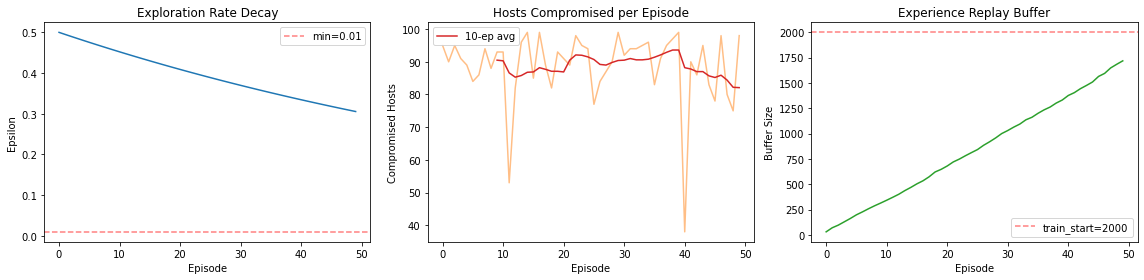

In [9]:
log_df = pd.DataFrame(training_log)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Epsilon decay
axes[0].plot(log_df["episode"], log_df["epsilon"], color="tab:blue")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Epsilon")
axes[0].set_title("Exploration Rate Decay")
axes[0].axhline(y=EPSILON_MIN, color="red", linestyle="--", alpha=0.5, label=f"min={EPSILON_MIN}")
axes[0].legend()

# Compromised hosts per episode
axes[1].plot(log_df["episode"], log_df["compromised_hosts"], color="tab:orange", alpha=0.5)
axes[1].plot(log_df["episode"], log_df["compromised_hosts"].rolling(10).mean(), color="tab:red", label="10-ep avg")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Compromised Hosts")
axes[1].set_title("Hosts Compromised per Episode")
axes[1].legend()

# Memory buffer size
axes[2].plot(log_df["episode"], log_df["memory_size"], color="tab:green")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Buffer Size")
axes[2].set_title("Experience Replay Buffer")
axes[2].axhline(y=TRAIN_START, color="red", linestyle="--", alpha=0.5, label=f"train_start={TRAIN_START}")
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Run Simulations: AI vs Baselines

Run the trained model against baseline MTD schemes (random, alternative, simultaneous)
and no-MTD to compare security postures. Each simulation uses the same network parameters.

In [1]:
def run_simulation(scheme, trained_model=None, num_trials=5):
    """Run simulation trials and collect results.

    Returns a dict with aggregated security metrics across trials.
    """
    trial_results = []

    for trial in range(num_trials):
        env = simpy.Environment()
        end_event = env.event()
        security_metrics = SecurityMetricStatistics()

        network = TimeNetwork(
            total_nodes=TOTAL_NODES, total_endpoints=5,
            total_subnets=8, total_layers=4,
            total_database=2, terminate_compromise_ratio=0.8,
        )
        adversary = Adversary(network=network, attack_threshold=constants.ATTACKER_THRESHOLD)

        attack_op = AttackOperation(env=env, end_event=end_event, adversary=adversary, proceed_time=0)
        attack_op.proceed_attack()

        if scheme == "mtd_ai":
            mtd_op = MTDAIOperation(
                features=FEATURES,
                security_metrics_record=security_metrics,
                env=env, end_event=end_event,
                network=network, attack_operation=attack_op,
                scheme="mtd_ai", adversary=adversary,
                mtd_trigger_interval=MTD_INTERVAL,
                custom_strategies=MTD_STRATEGIES,
                main_network=trained_model,
                epsilon=0.01,  # near-greedy exploitation
                attacker_sensitivity=1.0,
                static_degrade_factor=2000,
            )
            mtd_op.proceed_mtd()
        elif scheme != "no_mtd":
            mtd_op = MTDOperation(
                security_metrics_record=security_metrics,
                env=env, end_event=end_event,
                network=network, attack_operation=attack_op,
                scheme=scheme, adversary=adversary,
            )
            mtd_op.proceed_mtd()
        # no_mtd: attack only, no defender

        env.run(until=FINISH_TIME)

        compromised = len(adversary.get_compromised_hosts())
        mtd_record = network.get_mtd_stats().get_record()
        attack_record = adversary.get_attack_stats().get_record()

        # Compute metrics
        mtd_count = len(mtd_record)
        compromise_ratio = compromised / TOTAL_NODES

        # MTTC: mean attack action duration per compromised host
        if compromised > 0 and "name" in attack_record.columns:
            attack_actions = attack_record[attack_record["name"].isin(["SCAN_PORT", "EXPLOIT_VULN", "BRUTE_FORCE"])]
            mttc = attack_actions["duration"].sum() / compromised
        else:
            mttc = FINISH_TIME  # no compromise = max time

        # Attack success rate
        if "name" in attack_record.columns:
            scan_ports = len(attack_record[attack_record["name"] == "SCAN_PORT"])
            asr = compromised / scan_ports if scan_ports > 0 else 0
        else:
            asr = 0

        trial_results.append({
            "compromised": compromised,
            "compromise_ratio": compromise_ratio,
            "mttc": mttc,
            "asr": asr,
            "mtd_count": mtd_count,
        })

    df = pd.DataFrame(trial_results)
    return {
        "compromised": df["compromised"].mean(),
        "compromise_ratio": df["compromise_ratio"].mean(),
        "mttc": df["mttc"].mean(),
        "asr": df["asr"].mean(),
        "mtd_count": df["mtd_count"].mean(),
        "raw": df,
    }

print("Simulation runner defined.")

Simulation runner defined.


In [3]:
%%time

# Load the trained model (in case this cell is run independently)
trained_model = load_model(MODEL_PATH)

NUM_TRIALS = 5
schemes = ["no_mtd", "random", "alternative", "simultaneous", "mtd_ai"]
results = {}

for scheme in schemes:
    print(f"Running {scheme}... ", end="", flush=True)
    model_arg = trained_model if scheme == "mtd_ai" else None
    results[scheme] = run_simulation(scheme, trained_model=model_arg, num_trials=NUM_TRIALS)
    r = results[scheme]
    print(f"compromised={r['compromised']:.1f}, MTTC={r['mttc']:.1f}, ASR={r['asr']:.4f}, MTDs={r['mtd_count']:.0f}")

print("\nAll simulations complete.")

NameError: name 'load_model' is not defined

## 6. Security Metrics Comparison

Compare the AI-driven MTD against baseline schemes across key metrics:
- **MTTC** (Mean Time to Compromise) - higher is better
- **ASR** (Attack Success Rate) - lower is better
- **Compromise Ratio** - lower is better
- **MTD Count** - deployments made during simulation

In [2]:
# Build comparison table
comparison = pd.DataFrame({
    scheme: {
        "Compromised Hosts": results[scheme]["compromised"],
        "Compromise Ratio": results[scheme]["compromise_ratio"],
        "MTTC (s)": results[scheme]["mttc"],
        "Attack Success Rate": results[scheme]["asr"],
        "MTD Deployments": results[scheme]["mtd_count"],
    }
    for scheme in schemes
}).T

comparison.index.name = "Scheme"
print("Mean results across", NUM_TRIALS, "trials:\n")
comparison

NameError: name 'pd' is not defined

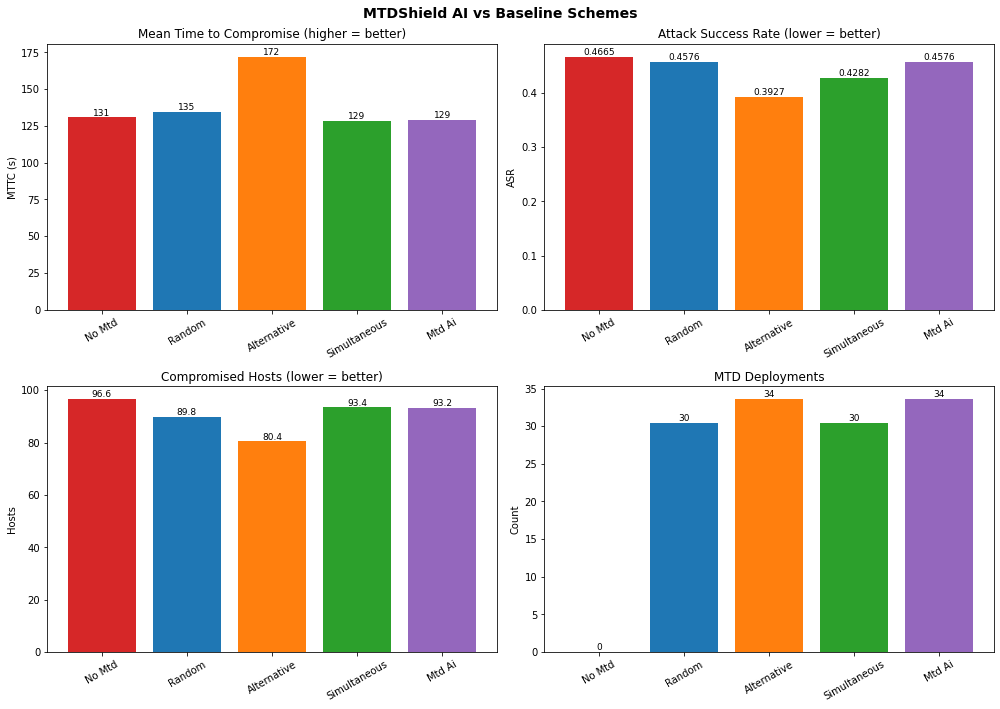

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scheme_labels = [s.replace("_", " ").title() for s in schemes]
colors = ["#d62728", "#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

# MTTC (higher = better)
mttc_vals = [results[s]["mttc"] for s in schemes]
bars = axes[0, 0].bar(scheme_labels, mttc_vals, color=colors)
axes[0, 0].set_title("Mean Time to Compromise (higher = better)")
axes[0, 0].set_ylabel("MTTC (s)")
axes[0, 0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, mttc_vals):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.0f}", ha="center", va="bottom", fontsize=9)

# ASR (lower = better)
asr_vals = [results[s]["asr"] for s in schemes]
bars = axes[0, 1].bar(scheme_labels, asr_vals, color=colors)
axes[0, 1].set_title("Attack Success Rate (lower = better)")
axes[0, 1].set_ylabel("ASR")
axes[0, 1].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, asr_vals):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.4f}", ha="center", va="bottom", fontsize=9)

# Compromised hosts (lower = better)
comp_vals = [results[s]["compromised"] for s in schemes]
bars = axes[1, 0].bar(scheme_labels, comp_vals, color=colors)
axes[1, 0].set_title("Compromised Hosts (lower = better)")
axes[1, 0].set_ylabel("Hosts")
axes[1, 0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, comp_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.1f}", ha="center", va="bottom", fontsize=9)

# MTD deployments
mtd_vals = [results[s]["mtd_count"] for s in schemes]
bars = axes[1, 1].bar(scheme_labels, mtd_vals, color=colors)
axes[1, 1].set_title("MTD Deployments")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, mtd_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.0f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("MTDShield AI vs Baseline Schemes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Normalised Radar Plot

Normalise all metrics against the no-MTD baseline (as in thesis Section 5.1) to
show relative improvement. Values > 1.0 for MTTC and < 1.0 for ASR/compromise
indicate the defence is outperforming the baseline.

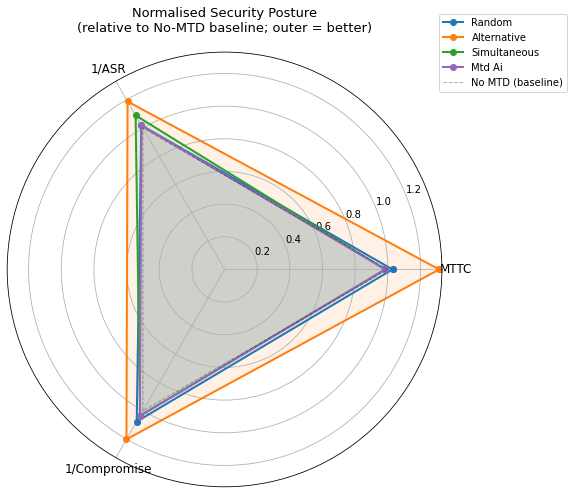

In [10]:
from math import pi

baseline = results["no_mtd"]
metrics = ["MTTC", "1/ASR", "1/Compromise"]
defense_schemes = ["random", "alternative", "simultaneous", "mtd_ai"]

# Normalise: MTTC (higher=better), inverted ASR and compromise (lower=better)
radar_data = {}
for scheme in defense_schemes:
    r = results[scheme]
    mttc_norm = r["mttc"] / baseline["mttc"] if baseline["mttc"] > 0 else 1
    asr_norm = (baseline["asr"] / r["asr"]) if r["asr"] > 0 else 1
    comp_norm = (baseline["compromise_ratio"] / r["compromise_ratio"]) if r["compromise_ratio"] > 0 else 1
    radar_data[scheme] = [mttc_norm, asr_norm, comp_norm]

# Radar plot
angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = {"random": "#1f77b4", "alternative": "#ff7f0e", "simultaneous": "#2ca02c", "mtd_ai": "#9467bd"}

for scheme in defense_schemes:
    values = radar_data[scheme] + radar_data[scheme][:1]
    label = scheme.replace("_", " ").title()
    ax.plot(angles, values, "o-", linewidth=2, label=label, color=radar_colors[scheme])
    ax.fill(angles, values, alpha=0.1, color=radar_colors[scheme])

# Baseline reference circle at 1.0
ax.plot(angles, [1.0] * (len(metrics) + 1), "k--", linewidth=1, alpha=0.3, label="No MTD (baseline)")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)
ax.set_title("Normalised Security Posture\n(relative to No-MTD baseline; outer = better)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 8. Detailed AI Simulation Run with Logging

Run a single AI simulation with full logging enabled to inspect exactly what the
model does: which MTD techniques it selects, when it deploys them, and how the
attack progresses.

In [12]:
# Single detailed run
env = simpy.Environment()
end_event = env.event()
security_metrics = SecurityMetricStatistics()

detail_network = TimeNetwork(
    total_nodes=TOTAL_NODES, total_endpoints=5,
    total_subnets=8, total_layers=4,
    total_database=2, terminate_compromise_ratio=0.8,
)
detail_adversary = Adversary(network=detail_network, attack_threshold=constants.ATTACKER_THRESHOLD)

detail_attack = AttackOperation(env=env, end_event=end_event, adversary=detail_adversary, proceed_time=0)
detail_attack.proceed_attack()

detail_ai = MTDAIOperation(
    features=FEATURES,
    security_metrics_record=security_metrics,
    env=env, end_event=end_event,
    network=detail_network, attack_operation=detail_attack,
    scheme="mtd_ai", adversary=detail_adversary,
    mtd_trigger_interval=MTD_INTERVAL,
    custom_strategies=MTD_STRATEGIES,
    main_network=trained_model,
    epsilon=0.01,
    attacker_sensitivity=1.0,
    static_degrade_factor=2000,
)
detail_ai.proceed_mtd()

env.run(until=FINISH_TIME)

compromised = len(detail_adversary.get_compromised_hosts())
print(f"Simulation ended at t={env.now:.0f}s")
print(f"Compromised: {compromised}/{TOTAL_NODES} ({compromised/TOTAL_NODES*100:.1f}%)")
print(f"Target compromised: {detail_adversary.target_compromised}")

Simulation ended at t=15000s
Compromised: 92/100 (92.0%)
Target compromised: False


### 8a. MTD Deployment Log

The MTD statistics record shows every technique deployed, when it started/finished,
and how long it took.

Total MTD deployments: 26
Attacks interrupted: 24



,name,start_time,finish_time,duration,executed_at
0,OSDiversity,0.000000,80.100301,80.100301,application
1,OSDiversity,200.744089,280.795344,80.051255,application
2,IPShuffle,402.495659,512.609396,110.113737,network
3,IPShuffle,604.174446,714.691338,110.516891,network
4,IPShuffle,804.563794,914.915276,110.351482,network
5,IPShuffle,1005.185723,1115.284422,110.098699,network
6,IPShuffle,1205.517207,1316.458479,110.941272,network
7,IPShuffle,1406.174025,1516.326844,110.152819,network
8,IPShuffle,1606.816540,1716.970347,110.153808,network
9,IPShuffle,1807.611020,1917.805607,110.194587,network



--- MTD Technique Selection Distribution ---
IPShuffle      20
OSDiversity     6
Name: name, dtype: int64


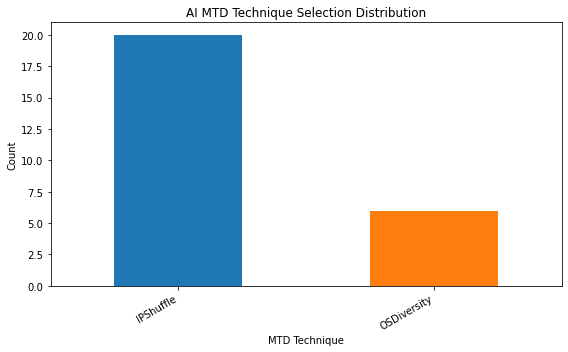

In [7]:
mtd_record = detail_network.get_mtd_stats().get_record()
print(f"Total MTD deployments: {len(mtd_record)}")
print(f"Attacks interrupted: {detail_network.get_mtd_stats().get_total_attack_interrupted()}\n")

if len(mtd_record) > 0:
    # Show first 20 rows
    display(mtd_record.head(20))

    # MTD technique distribution
    print("\n--- MTD Technique Selection Distribution ---")
    if "name" in mtd_record.columns:
        technique_counts = mtd_record["name"].value_counts()
        print(technique_counts)

        fig, ax = plt.subplots(figsize=(8, 5))
        technique_counts.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][:len(technique_counts)])
        ax.set_title("AI MTD Technique Selection Distribution")
        ax.set_ylabel("Count")
        ax.set_xlabel("MTD Technique")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No MTD deployments recorded.")

### 8b. Attack Operation Log

The attack statistics record shows every action the adversary took during the simulation.

In [8]:
attack_record = detail_adversary.get_attack_stats().get_record()
print(f"Total attack actions: {len(attack_record)}")

if len(attack_record) > 0:
    # Show first 20 rows
    display(attack_record.head(20))

    # Attack action distribution
    if "name" in attack_record.columns:
        print("\n--- Attack Action Distribution ---")
        action_counts = attack_record["name"].value_counts()
        print(action_counts)

    # Compromises over time
    if "compromise_host_uuid" in attack_record.columns:
        compromises = attack_record[attack_record["compromise_host_uuid"] != "None"]
        if len(compromises) > 0:
            print(f"\n--- Compromise Events: {len(compromises)} ---")
            display(compromises[["name", "start_time", "finish_time", "compromise_host_uuid"]].head(20))

Total attack actions: 1541


,name,start_time,finish_time,duration,current_host,current_host_uuid,compromise_host,compromise_host_uuid,current_host_attempt,cumulative_attempts,cumulative_compromised_hosts,compromise_users,interrupted_in,interrupted_by
0,SCAN_HOST,0.000000,5.000000,5.000000,-1,-1,None,None,0,0,0,[],None,None
1,ENUM_HOST,5.000000,10.000000,5.000000,-1,-1,None,None,0,0,0,[],None,None
2,SCAN_PORT,10.000000,35.000000,25.000000,0,41617455-b490-41ce-b364-ae808f592168,None,None,1,0,0,[],None,None
3,EXPLOIT_VULN,35.000000,38.252578,3.252578,0,41617455-b490-41ce-b364-ae808f592168,None,None,1,0,0,[],None,None
4,EXPLOIT_VULN,38.252578,38.562872,0.310294,0,41617455-b490-41ce-b364-ae808f592168,None,None,1,1,0,[],None,None
5,EXPLOIT_VULN,38.562872,49.900447,11.337575,0,41617455-b490-41ce-b364-ae808f592168,None,None,1,2,0,[],None,None
6,EXPLOIT_VULN,49.900447,52.477538,2.577091,0,41617455-b490-41ce-b364-ae808f592168,None,None,1,3,0,[],None,None
7,EXPLOIT_VULN,52.477538,66.609635,14.132097,0,41617455-b490-41ce-b364-ae808f592168,None,None,1,4,0,[],None,None
8,EXPLOIT_VULN,66.609635,73.732675,7.123040,0,41617455-b490-41ce-b364-ae808f592168,None,None,1,5,0,[],None,None
9,EXPLOIT_VULN,73.732675,80.100301,6.367625,0,41617455-b490-41ce-b364-ae808f592168,None,None,1,6,0,[],application,OSDiversity



--- Attack Action Distribution ---
EXPLOIT_VULN     662
ENUM_HOST        389
SCAN_PORT        215
BRUTE_FORCE       98
SCAN_NEIGHBOR     97
SCAN_HOST         80
Name: name, dtype: int64

--- Compromise Events: 97 ---


,name,start_time,finish_time,compromise_host_uuid
48,EXPLOIT_VULN,435.669426,446.466023,41617455-b490-41ce-b364-ae808f592168
78,EXPLOIT_VULN,682.278596,690.861511,36256f0e-0dbc-417d-b7d7-f813d52e192f
145,EXPLOIT_VULN,1248.846738,1255.870232,3a4a3cc1-9392-4f66-be5e-c2c6a42b27df
164,EXPLOIT_VULN,1403.816385,1412.326624,3e993d26-b071-459f-9990-57af42693e2b
194,EXPLOIT_VULN,1591.608305,1606.900423,ad467a5e-0a08-4701-b757-6f9dd3ab4d90
208,EXPLOIT_VULN,1693.805174,1701.822142,3e97cd99-2f34-46c7-bd17-16b4b9bf153b
230,EXPLOIT_VULN,1865.382944,1871.225465,d2935345-d87a-4571-8f9d-f0ad8a3004a9
295,EXPLOIT_VULN,2420.640025,2428.399839,4eb03574-b505-4891-b4d9-8b7cce1440c3
302,EXPLOIT_VULN,2477.269206,2484.009171,3dd863f8-7474-4a30-9f77-8c8c72c07106
315,EXPLOIT_VULN,2627.512584,2633.233549,a88b643c-a8dd-471f-92c6-b69a007366c1


### 8c. MTD Deployment Timeline

Visualise when each MTD technique was deployed over the simulation timeline,
alongside compromise events.

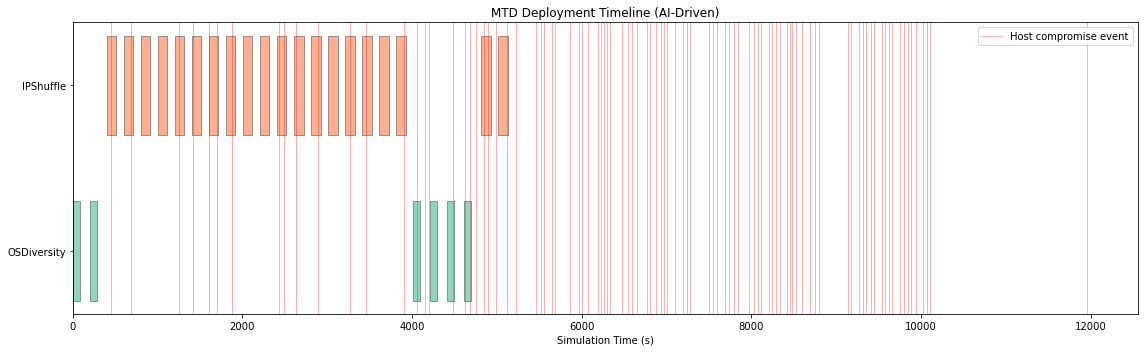

In [9]:
if len(mtd_record) > 0 and "name" in mtd_record.columns:
    fig, ax = plt.subplots(figsize=(16, 5))

    # Map technique names to y-positions
    technique_names = mtd_record["name"].unique()
    technique_y = {name: i for i, name in enumerate(technique_names)}
    mtd_colors = {name: plt.cm.Set2(i) for i, name in enumerate(technique_names)}

    # Plot MTD deployments as horizontal bars
    for _, row in mtd_record.iterrows():
        y = technique_y[row["name"]]
        ax.barh(y, row["duration"], left=row["start_time"],
                height=0.6, color=mtd_colors[row["name"]], alpha=0.7, edgecolor="black", linewidth=0.5)

    ax.set_yticks(range(len(technique_names)))
    ax.set_yticklabels(technique_names)
    ax.set_xlabel("Simulation Time (s)")
    ax.set_title("MTD Deployment Timeline (AI-Driven)")

    # Overlay compromise events as vertical lines
    if len(attack_record) > 0 and "compromise_host_uuid" in attack_record.columns:
        compromises = attack_record[attack_record["compromise_host_uuid"] != "None"]
        for _, row in compromises.iterrows():
            ax.axvline(x=row["finish_time"], color="red", alpha=0.3, linewidth=1)
        if len(compromises) > 0:
            ax.axvline(x=0, color="red", alpha=0.3, linewidth=1, label="Host compromise event")
            ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No MTD data to plot.")

### 8d. Security Metric Tracker

The `SecurityMetricStatistics` counts how many times each MTD technique was
selected by the AI during the simulation.

AI MTD Selection Counts (SecurityMetricStatistics):
{'CompleteTopologyShuffle': 0, 'IPShuffle': 22, 'OSDiversity': 6, 'ServiceDiversity': 0}


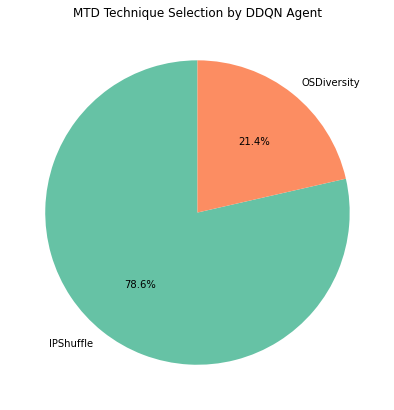

In [10]:
print("AI MTD Selection Counts (SecurityMetricStatistics):")
print(security_metrics._metric_record)

# Pie chart of selections
counts = security_metrics._metric_record
if any(v > 0 for v in counts.values()):
    labels = [k for k, v in counts.items() if v > 0]
    values = [v for v in counts.values() if v > 0]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie(values, labels=labels, autopct="%1.1f%%", startangle=90,
           colors=plt.cm.Set2.colors[:len(labels)])
    ax.set_title("MTD Technique Selection by DDQN Agent")
    plt.show()
else:
    print("No selections recorded.")

## 9. Model Summary

The trained model is saved at `src/mtdsim/ai/models/main_network_flagship.h5` and
can be loaded for future experiments:

```python
from tensorflow.keras.models import load_model
model = load_model("src/mtdsim/ai/models/main_network_flagship.h5")
```

**Hyperparameters used (Tay 2024 best):**

| Parameter | Value |
|---|---|
| gamma | 0.85 |
| epsilon (initial) | 0.5 |
| epsilon_decay | 0.99 |
| epsilon_min | 0.01 |
| batch_size | 64 |
| train_start | 2000 |
| episodes | 200 |
| finish_time | 15000 |
| total_nodes | 100 |
| state features | 5 static + 6 time-series |
| actions | 5 (4 MTD + do nothing) |

## Original Prompt

Please help me retrain joo kai's flagship RL model, retrieve from version control. Please read @2024-tay_mtdshield.txt   , look in version control, look at the best model joo kai decides so that I can use as a benchmark for further research. Please decide how it should be maintained in this new directory structure. To signal completion of this task, please write @notebooks/2026-03-29_MTDSim_RetrainMTDAI.ipynb    to use this trained model in the simulator, and i want to be able to visualise and see how it works by running the simulator with it (possibly reading logs etc.)
